# Traffic Incident Severity Mining

## An end-to-end, leakage-aware classification workflow

This notebook predicts traffic-incident severity from report text, time, location, weather, and road-condition signals. It documents each stage of the workflow—from data quality checks to final evaluation—with **macro F1** as the primary metric for the imbalanced target classes.

# 1. Data loading and initial inspection

Import the libraries and set shared configuration. Results are written to `results/` so the key outputs remain easy to review.

In [ ]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display, Markdown
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import LinearSVC
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                            confusion_matrix, classification_report)

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
RANDOM_STATE = 42
PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "data").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_DIR = PROJECT_ROOT / "data"
RESULTS_DIR = PROJECT_ROOT / "results"
RESULTS_DIR.mkdir(exist_ok=True)

### Load the training data

Read `../data/data.csv` and inspect a small sample, its dimensions, and the available fields.

In [2]:
df = pd.read_csv(DATA_DIR / "data.csv")
df.head()

,f1,f2,f3,f4,f5,f6,f7,f8,f9,f10,...,f26,f27,f28,f29,f30,f31,f32,f33,f34,y
0,Source1,2020-12-24 10:08:43,2020-12-24 11:08:43,42.687721,-123.392106,42.690302,-123.393621,0.194,A crash has occurred causing no to minimum del...,I-5 N,...,False,False,False,False,False,False,False,False,Day,2
1,Source1,2022-06-09 16:01:34.000000000,2022-06-09 17:16:23.000000000,41.268605,-73.606244,41.275247,-73.577968,1.538,Slow traffic on NY-35 - NY-124 from NY-121/N S...,N Salem Rd,...,False,False,False,False,False,False,False,False,Day,2
2,Source2,2016-10-14 11:12:59,2016-10-14 11:56:56,30.758549,-98.226692,NaN,NaN,0.010,Accident on TX-29 Polk St at Pierce St.,N Pierce St,...,False,False,False,False,False,False,False,False,Day,2
3,Source1,2020-05-29 18:17:05,2020-05-29 19:17:05,34.134470,-78.875060,34.134470,-78.875060,0.000,At US-701 - Accident.,Highway 701 N,...,False,False,False,False,False,False,False,False,Day,2
4,Source2,2020-02-18 09:36:33,2020-02-18 10:22:00,30.381618,-97.651863,NaN,NaN,0.000,Accident on Dessau Rd near FM-734 Parmer Ln.,Dessau Rd,...,False,False,False,False,False,False,False,False,Day,2


Check the dataset size and column names.

In [3]:
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())

Shape: (100000, 35)
Columns: ['f1', 'f2', 'f3', 'f4', 'f5', 'f6', 'f7', 'f8', 'f9', 'f10', 'f11', 'f12', 'f13', 'f14', 'f15', 'f16', 'f17', 'f18', 'f19', 'f20', 'f21', 'f22', 'f23', 'f24', 'f25', 'f26', 'f27', 'f28', 'f29', 'f30', 'f31', 'f32', 'f33', 'f34', 'y']


Check each column's data type.

In [4]:
df.dtypes.to_frame('dtype')

,dtype
f1,str
f2,str
f3,str
f4,float64
f5,float64
f6,float64
f7,float64
f8,float64
f9,str
f10,str


Use `y` as the target.

In [5]:
target_column = "y"
print("Target column:", target_column)
print("Target classes:", sorted(df[target_column].unique().tolist()))

Target column: y
Target classes: [1, 2, 3, 4]


Identify each column's general role without renaming it.

In [6]:
feature_columns = [c for c in df.columns if c != target_column]
boolean_columns = df[feature_columns].select_dtypes(include="bool").columns.tolist()
numeric_columns = df[feature_columns].select_dtypes(include=np.number).columns.tolist()
object_columns = df[feature_columns].select_dtypes(include=["object", "string"]).columns.tolist()

datetime_like_columns = []
for c in object_columns:
    sample = df[c].dropna().astype(str).head(1000)
    parsed = pd.to_datetime(sample, errors="coerce")
    if len(sample) and parsed.notna().mean() >= 0.90:
        datetime_like_columns.append(c)

remaining_objects = [c for c in object_columns if c not in datetime_like_columns]
text_like_columns = [c for c in remaining_objects if df[c].nunique(dropna=True) > 1000 and df[c].dropna().astype(str).str.len().mean() > 30]
categorical_columns = [c for c in remaining_objects if c not in text_like_columns]

column_roles = pd.DataFrame({
    "role": ["numeric", "categorical", "boolean", "datetime-like", "text-like"],
    "columns": [numeric_columns, categorical_columns, boolean_columns,
                datetime_like_columns, text_like_columns]
})
display(column_roles)

,role,columns
0,numeric,"[f4, f5, f6, f7, f8, f16, f17, f18, f19, f21, ..."
1,categorical,"[f1, f2, f3, f10, f11, f12, f13, f14, f20, f34]"
2,boolean,"[f23, f24, f25, f26, f27, f28, f29, f30, f31, ..."
3,datetime-like,[f15]
4,text-like,[f9]


# 2. Data quality checks and cleaning

Review data quality before modelling. These checks keep the original fields intact while making the later preprocessing decisions explicit.

In [7]:
missing_table = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_percent": 100 * df.isna().mean()
}).sort_values("missing_percent", ascending=False)
display(missing_table[missing_table.missing_count > 0])

,missing_count,missing_percent
f6,44131,44.131
f7,44131,44.131
f22,28673,28.673
f21,7436,7.436
f19,2317,2.317
f20,2298,2.298
f17,2254,2.254
f16,2133,2.133
f18,1858,1.858
f15,1563,1.563


Count exact duplicates to prevent train-test overlap.

In [8]:
duplicate_count = int(df.duplicated().sum())
print("Duplicated rows:", duplicate_count)

Duplicated rows: 18


Remove exact duplicates only.

In [9]:
original_shape = df.shape
if duplicate_count:
    df = df.drop_duplicates().reset_index(drop=True)
print("Shape before:", original_shape)
print("Shape after: ", df.shape)

Shape before: (100000, 35)
Shape after:  (99982, 35)


Check extra whitespace and infinite values.

In [10]:
whitespace_counts = {
    c: int((df[c].dropna().astype(str) != df[c].dropna().astype(str).str.strip()).sum())
    for c in object_columns
}
print("Columns with surrounding whitespace:", {k: v for k, v in whitespace_counts.items() if v})
print("Infinite numeric values:", int(np.isinf(df[numeric_columns]).sum().sum()))

Columns with surrounding whitespace: {'f9': 66, 'f10': 21984}
Infinite numeric values: 0


Find boolean-like columns.

In [11]:
boolean_like = boolean_columns.copy()
for c in object_columns:
    values = set(df[c].dropna().astype(str).str.lower().unique())
    if values and values <= {"true", "false", "yes", "no", "0", "1"}:
        boolean_like.append(c)
print("Boolean-like columns:", boolean_like)

Boolean-like columns: ['f23', 'f24', 'f25', 'f26', 'f27', 'f28', 'f29', 'f30', 'f31', 'f32', 'f33']


Find datetime-like columns.

In [12]:
print('Datetime-like columns:', datetime_like_columns)

Datetime-like columns: ['f15']


Find long, high-cardinality text columns.

In [13]:
print('Text-like columns:', text_like_columns)

Text-like columns: ['f9']


Flag possible outliers with the IQR rule, but keep them.

In [14]:
outlier_rows = []
for c in numeric_columns:
    q1, q3 = df[c].quantile([0.25, 0.75])
    iqr = q3 - q1
    count = int(((df[c] < q1 - 1.5 * iqr) | (df[c] > q3 + 1.5 * iqr)).sum())
    outlier_rows.append((c, count, 100 * count / len(df)))
outlier_table = pd.DataFrame(outlier_rows, columns=["feature", "iqr_outliers", "percent"])
display(outlier_table.sort_values("percent", ascending=False))

,feature,iqr_outliers,percent
8,f19,19219,19.222460
4,f8,12416,12.418235
10,f22,6892,6.893241
7,f18,5843,5.844052
9,f21,2819,2.819508
5,f16,654,0.654118
0,f4,0,0.000000
1,f5,0,0.000000
2,f6,0,0.000000
3,f7,0,0.000000


# 3. Exploratory data analysis

Explore the target distribution and predictor patterns. Because the severity classes are imbalanced, **macro F1** is the main selection metric: every class contributes equally.

,count,percent
y,,
1,830,0.83
2,79611,79.63
3,16789,16.79
4,2752,2.75


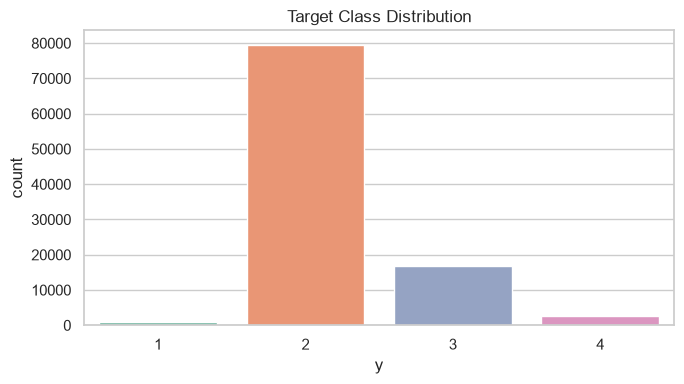

In [15]:
target_counts = df[target_column].value_counts().sort_index()
target_percent = (100 * df[target_column].value_counts(normalize=True).sort_index()).round(2)
display(pd.DataFrame({"count": target_counts, "percent": target_percent}))

plt.figure(figsize=(7, 4))
sns.countplot(data=df, x=target_column, hue=target_column, palette="Set2", legend=False)
plt.title("Target Class Distribution")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "target_distribution.png", dpi=150)
plt.show()

Compare missing-value percentages.

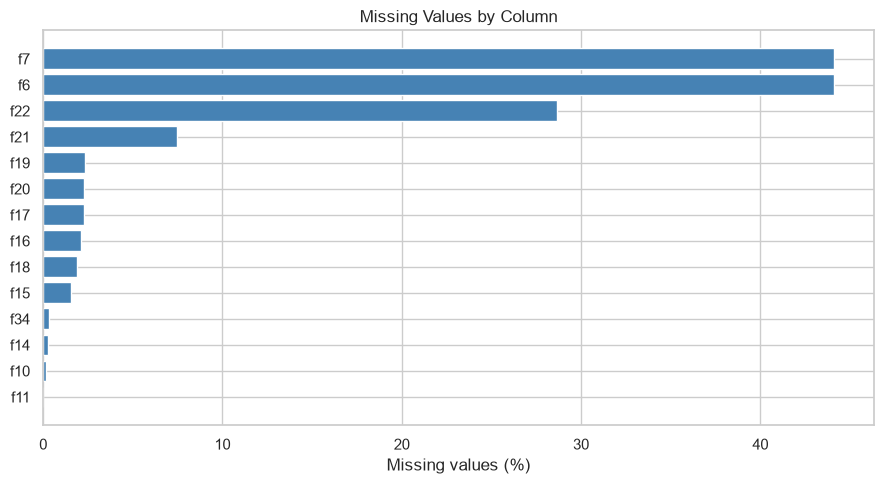

In [16]:
missing_plot_data = missing_table[missing_table.missing_count > 0].sort_values("missing_percent")
plt.figure(figsize=(9, 5))
plt.barh(missing_plot_data.index, missing_plot_data.missing_percent, color="steelblue")
plt.xlabel("Missing values (%)")
plt.title("Missing Values by Column")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "missing_values.png", dpi=150)
plt.show()

Plot up to 12 numeric distributions.

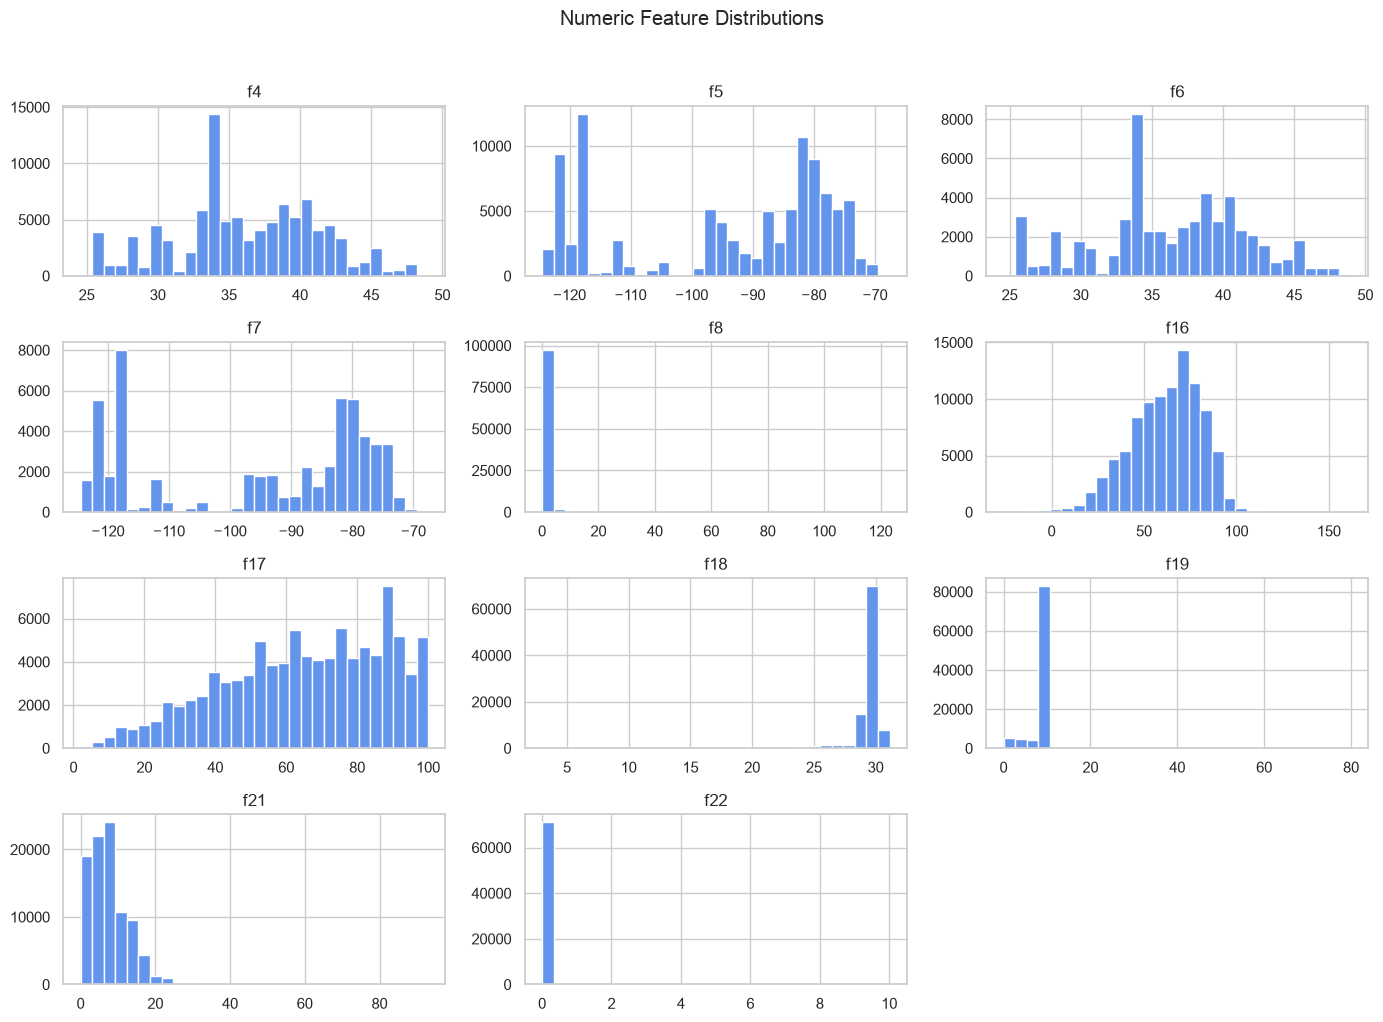

In [17]:
eda_numeric = numeric_columns[:12]
df[eda_numeric].hist(figsize=(14, 10), bins=30, color="cornflowerblue", edgecolor="white")
plt.suptitle("Numeric Feature Distributions", y=1.02)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "numeric_distributions.png", dpi=150, bbox_inches="tight")
plt.show()

Plot a readable sample of numeric values by class.

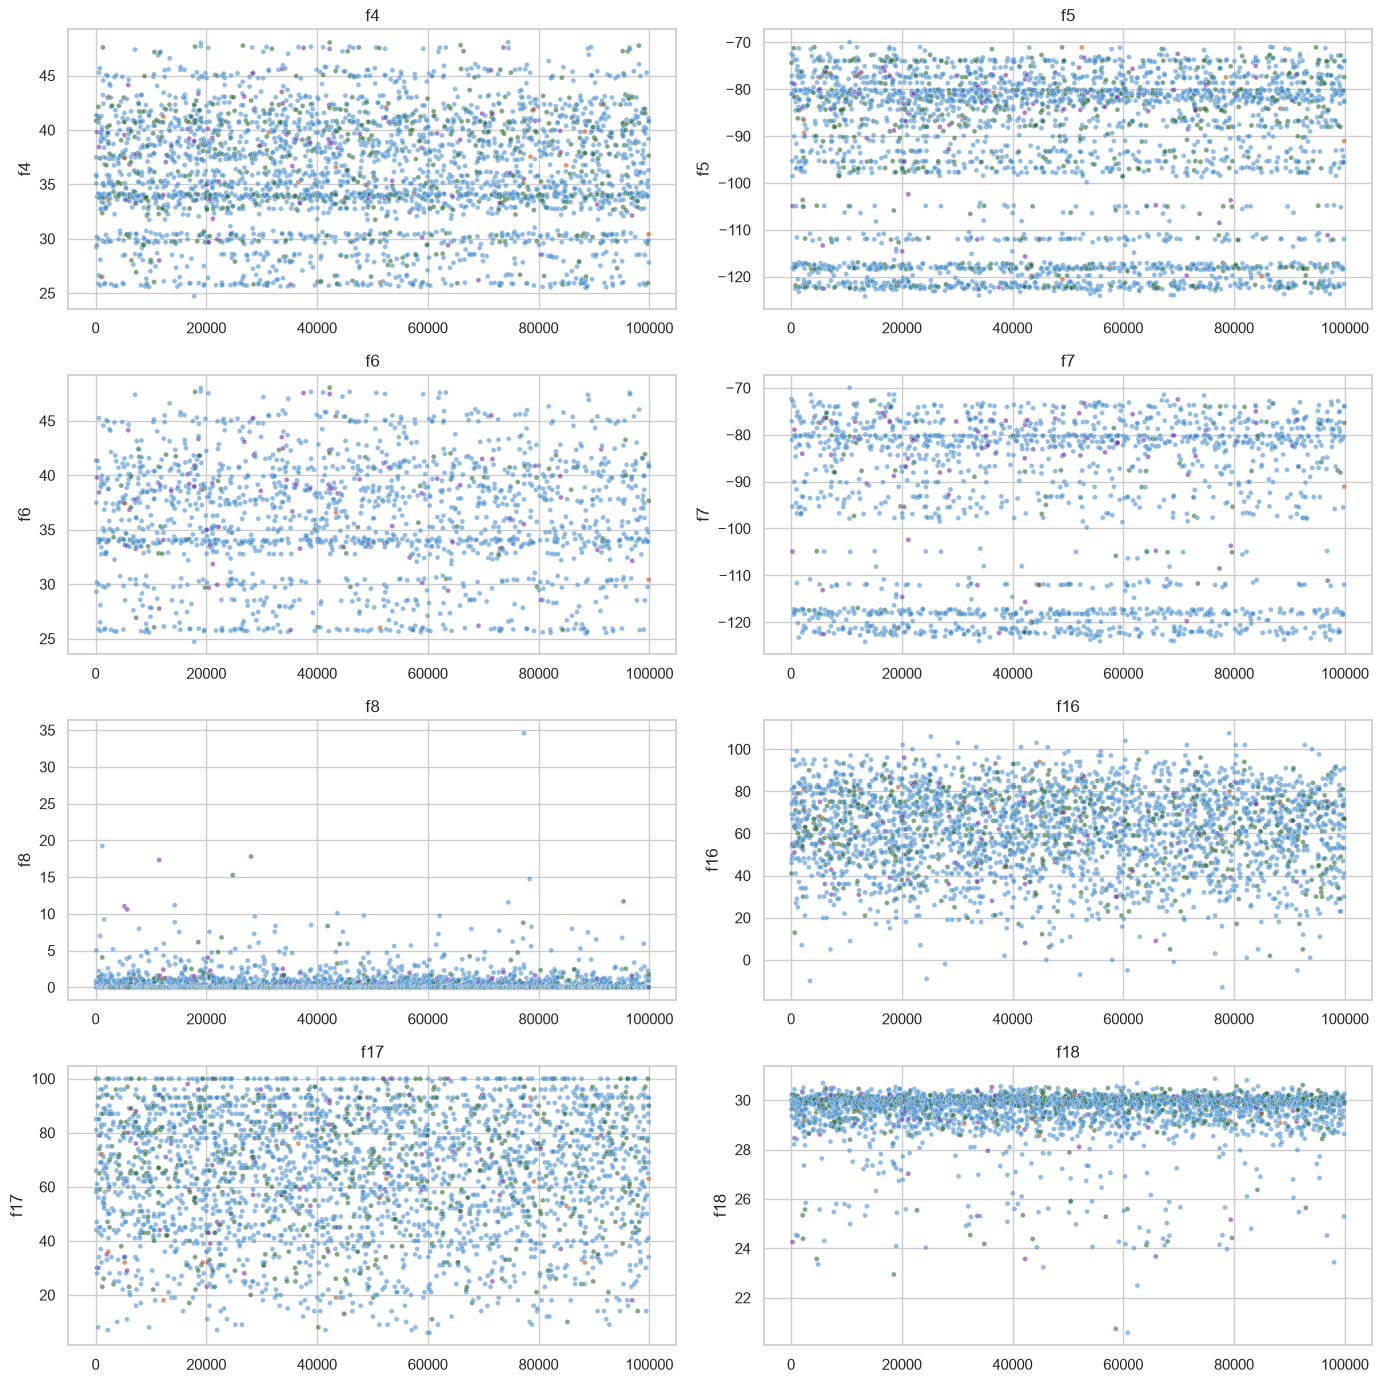

In [18]:
custom_class_palette = {
    1: "#B54708",
    2: "#3A86C8",
    3: "#1B5E20",
    4: "#6A1B9A"
}

plot_sample = df.sample(min(3000, len(df)), random_state=RANDOM_STATE).sort_index()
index_features = numeric_columns[:8]
fig, axes = plt.subplots(4, 2, figsize=(14, 14))
for ax, c in zip(axes.flat, index_features):
    sns.scatterplot(
        x=plot_sample.index, 
        y=plot_sample[c], 
        hue=plot_sample[target_column],
        palette=custom_class_palette, 
        s=13, 
        alpha=.55, 
        ax=ax, 
        legend=False
    )
    ax.set_title(c)
    ax.set_xlabel("")
plt.tight_layout()
plt.show()

Compare selected numeric features across classes.

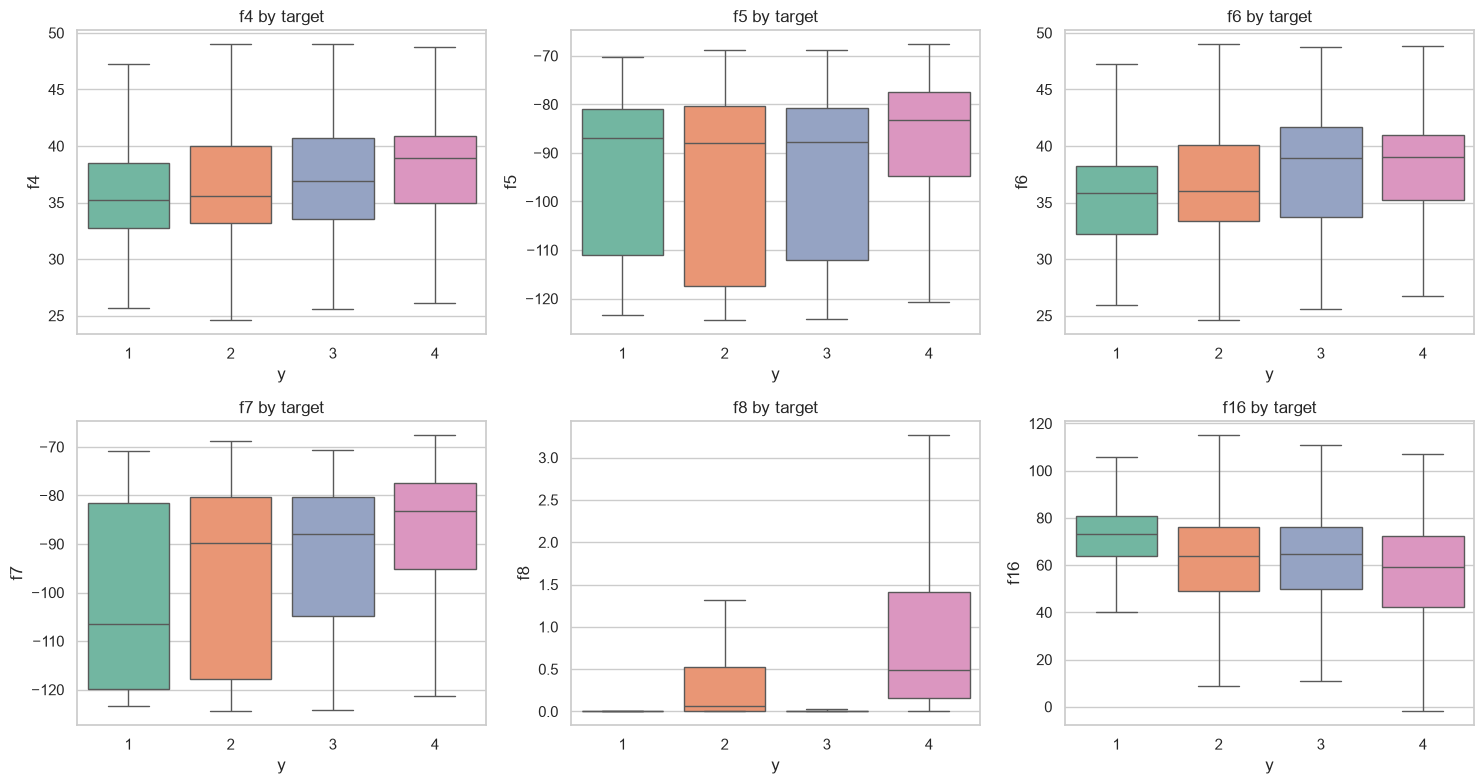

In [19]:
box_features = numeric_columns[:6]
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, c in zip(axes.flat, box_features):
    sns.boxplot(data=df, x=target_column, y=c, hue=target_column,
                palette="Set2", legend=False, showfliers=False, ax=ax)
    ax.set_title(f"{c} by target")
plt.tight_layout()
plt.show()

Compare low-cardinality categories across classes.

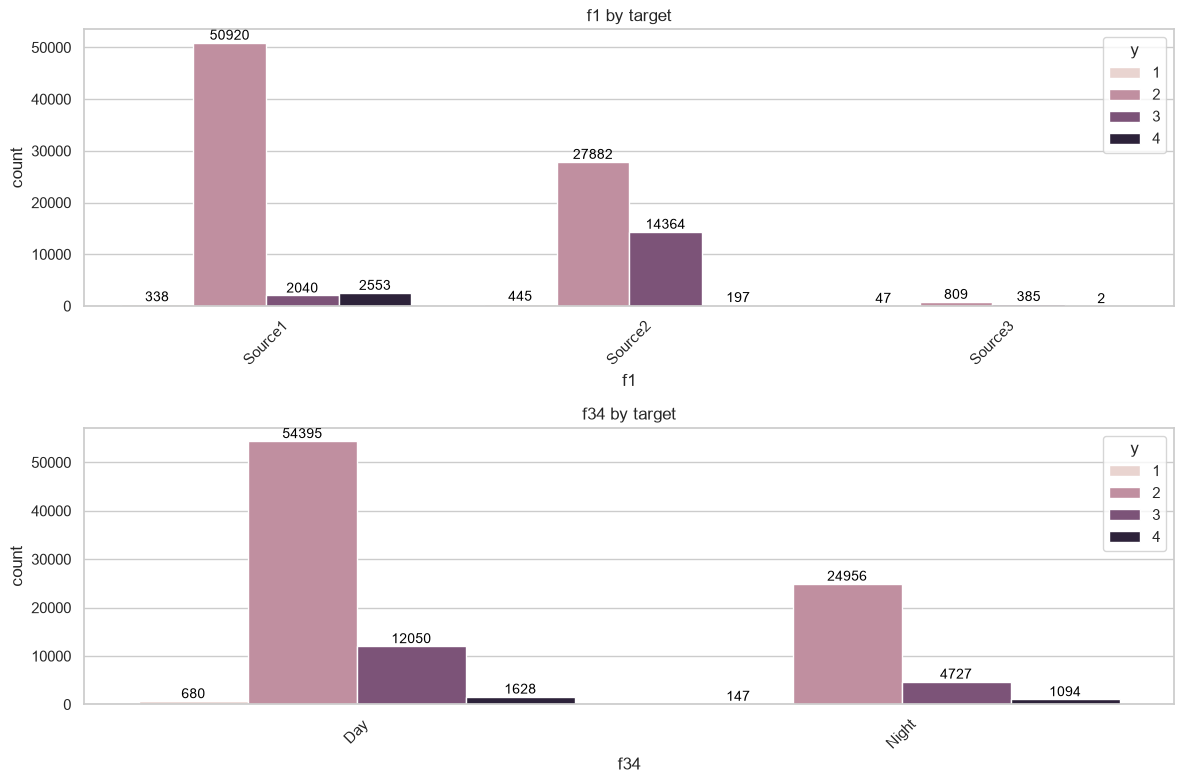

In [20]:
low_cardinality = [c for c in categorical_columns if df[c].nunique(dropna=True) <= 15][:4]
if low_cardinality:
    fig, axes = plt.subplots(len(low_cardinality), 1, figsize=(12, 4 * len(low_cardinality)), squeeze=False)
    for ax, c in zip(axes.flat, low_cardinality):
        sns.countplot(data=df, x=c, hue=target_column, ax=ax)
        ax.tick_params(axis="x", rotation=45)

        counts = df[c].value_counts(dropna=False)
        for p in ax.patches:
            # p.get_x() + p.get_width()/2 gives the center x position
            height = p.get_height()
            if height > 0:
                ax.annotate(f"{int(height)}", 
                            (p.get_x() + p.get_width() / 2., height),
                            ha='center', va='bottom', fontsize=10, color='black', rotation=0)
        ax.set_title(f"{c} by target")
    plt.tight_layout(); plt.show()
else:
    print("No low-cardinality categorical columns were found.")

Show the ten most common values in high-cardinality columns.

In [21]:
high_cardinality = [c for c in categorical_columns if df[c].nunique(dropna=True) > 15][:4]
for c in high_cardinality:
    print(f"Top categories for {c}:")
    display(df[c].value_counts(dropna=False).head(10).to_frame("count"))

Top categories for f2:


,count
f2,
2021-01-26 16:16:13,5
2021-09-29 14:16:30,4
2021-11-21 18:37:51,4
2021-12-15 16:05:41,4
2022-01-21 22:32:38,3
2021-02-03 14:34:30,3
2023-02-15 17:27:00,3
2021-11-05 13:31:42,3
2021-10-20 09:20:00,3


Top categories for f3:


,count
f3,
2021-11-22 08:00:00,4
2023-02-15 19:00:00,3
2022-03-09 07:30:00,3
2021-02-04 19:48:55,2
2017-05-22 12:29:40,2
2022-06-27 18:45:00,2
2018-03-26 17:25:28,2
2022-01-22 00:12:27,2
2020-12-28 22:11:49,2


Top categories for f10:


,count
f10,
I-95 N,1032
I-95 S,923
I-5 N,911
I-10 E,760
I-5 S,686
I-10 W,641
I-80 W,516
I-80 E,486
I-405 N,400


Top categories for f11:


,count
f11,
Miami,2381
Houston,2201
Los Angeles,2009
Charlotte,1849
Dallas,1653
Orlando,1508
Austin,1300
Raleigh,1097
Baton Rouge,924


Check numeric correlations and possible redundancy.

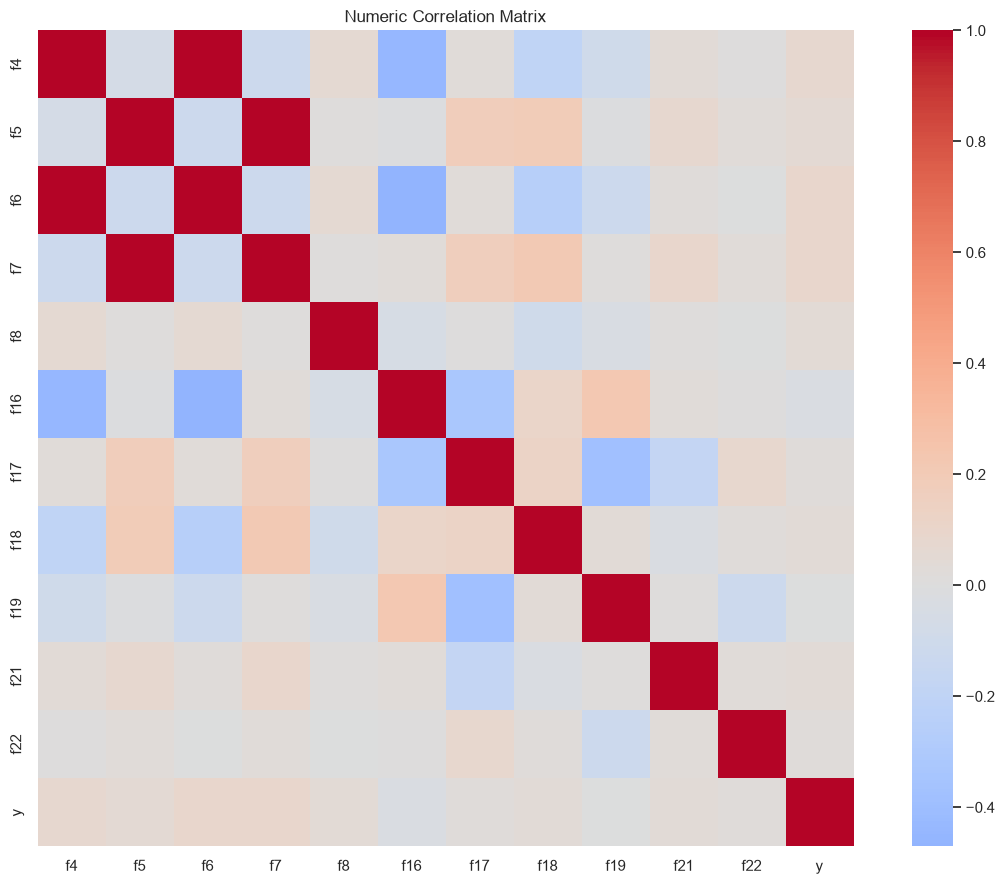

In [22]:
plt.figure(figsize=(12, 9))
corr = df[numeric_columns + [target_column]].corr()
sns.heatmap(corr, cmap="coolwarm", center=0, square=True)
plt.title("Numeric Correlation Matrix")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "correlation_matrix.png", dpi=150)
plt.show()

# 4. Feature engineering

Create interpretable features using predictors only, then remove raw text and datetime fields after extracting their useful signal.

In [23]:
def create_features(data):
    out = data.copy()
    created = []

    # Datetime features: f2 resembles start time and f3 resembles end time.
    if {"f2", "f3"}.issubset(out.columns):
        start = pd.to_datetime(out["f2"], errors="coerce")
        end = pd.to_datetime(out["f3"], errors="coerce")
        out["duration_minutes"] = (end - start).dt.total_seconds() / 60
        out["start_hour"] = start.dt.hour
        out["start_month"] = start.dt.month
        out["start_dayofweek"] = start.dt.dayofweek
        out["is_weekend"] = start.dt.dayofweek.isin([5, 6]).astype(int)
        created += ["duration_minutes", "start_hour", "start_month", "start_dayofweek", "is_weekend"]

    # f9 is the detected long text description.
    if "f9" in out.columns:
        text = out["f9"].fillna("").astype(str).str.lower()
        out["text_length"] = text.str.len()
        out["word_count"] = text.str.split().str.len()
        created += ["text_length", "word_count"]
        for word in ["accident", "crash", "traffic", "delay", "blocked", "closed"]:
            name = f"has_{word}"
            out[name] = text.str.contains(word, regex=False).astype(int)
            created.append(name)

    # f4:f7 have latitude/longitude ranges and resemble start/end coordinates.
    if {"f4", "f5", "f6", "f7"}.issubset(out.columns):
        out["latitude_difference"] = (out["f6"] - out["f4"]).abs()
        out["longitude_difference"] = (out["f7"] - out["f5"]).abs()
        out["coordinate_difference"] = np.sqrt(out["latitude_difference"]**2 + out["longitude_difference"]**2)
        created += ["latitude_difference", "longitude_difference", "coordinate_difference"]

    # Raw datetimes and long free text would otherwise create thousands of categories.
    out = out.drop(columns=[c for c in ["f2", "f3", "f9", "f15"] if c in out.columns])
    return out, created

X_preview, created_features = create_features(df.drop(columns=target_column))
print("Created features:", created_features)
print("Feature matrix shape after creation:", X_preview.shape)

Created features: ['duration_minutes', 'start_hour', 'start_month', 'start_dayofweek', 'is_weekend', 'text_length', 'word_count', 'has_accident', 'has_crash', 'has_traffic', 'has_delay', 'has_blocked', 'has_closed', 'latitude_difference', 'longitude_difference', 'coordinate_difference']
Feature matrix shape after creation: (99982, 46)


Add time, text, keyword, and location-distance features.

# 5. Train–test split

Create a stratified 80/20 split. The test partition stays untouched until the final evaluation to prevent information leakage.

In [24]:
X_raw = df.drop(columns=target_column)
y = df[target_column].copy()
X, created_features = create_features(X_raw)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape: ", X_test.shape)
print("\ny_train distribution:")
display(y_train.value_counts(normalize=True).sort_index().to_frame("proportion"))
print("y_test distribution:")
display(y_test.value_counts(normalize=True).sort_index().to_frame("proportion"))

X_train shape: (79985, 46)
X_test shape:  (19997, 46)

y_train distribution:


,proportion
y,
1,0.008302
2,0.796249
3,0.167919
4,0.027530


y_test distribution:


,proportion
y,
1,0.008301
2,0.796269
3,0.167925
4,0.027504


# 6. Train-only preprocessing

Fit every preprocessing decision on the training partition only, then apply the same transformations to the test partition.

In [25]:
train_numeric = X_train.select_dtypes(include=[np.number, "bool"]).columns.tolist()
train_categorical = [c for c in X_train.columns if c not in train_numeric]
print("Numeric/boolean columns:", train_numeric)
print("Categorical columns:", train_categorical)

Numeric/boolean columns: ['f4', 'f5', 'f6', 'f7', 'f8', 'f16', 'f17', 'f18', 'f19', 'f21', 'f22', 'f23', 'f24', 'f25', 'f26', 'f27', 'f28', 'f29', 'f30', 'f31', 'f32', 'f33', 'duration_minutes', 'start_hour', 'start_month', 'start_dayofweek', 'is_weekend', 'text_length', 'word_count', 'has_accident', 'has_crash', 'has_traffic', 'has_delay', 'has_blocked', 'has_closed', 'latitude_difference', 'longitude_difference', 'coordinate_difference']
Categorical columns: ['f1', 'f10', 'f11', 'f12', 'f13', 'f14', 'f20', 'f34']


Fill numeric gaps with training medians.

In [26]:
numeric_medians = X_train[train_numeric].astype(float).median()
X_train_num = X_train[train_numeric].astype(float).fillna(numeric_medians)
X_test_num = X_test[train_numeric].astype(float).fillna(numeric_medians)

Fill categorical gaps with training modes.

In [27]:
category_fill_values = {}
for c in train_categorical:
    mode = X_train[c].mode(dropna=True)
    category_fill_values[c] = mode.iloc[0] if len(mode) else "Missing"

X_train_cat = X_train[train_categorical].copy()
X_test_cat = X_test[train_categorical].copy()
for c in train_categorical:
    X_train_cat[c] = X_train_cat[c].fillna(category_fill_values[c]).astype(str).str.strip()
    X_test_cat[c] = X_test_cat[c].fillna(category_fill_values[c]).astype(str).str.strip()

Group rare categories as `Other`, then one-hot encode them.

In [28]:
kept_categories = {}
for c in train_categorical:
    counts = X_train_cat[c].value_counts()
    kept_categories[c] = counts.index.tolist() if len(counts) <= 15 else counts.head(10).index.tolist()
    X_train_cat[c] = X_train_cat[c].where(X_train_cat[c].isin(kept_categories[c]), "Other")
    X_test_cat[c] = X_test_cat[c].where(X_test_cat[c].isin(kept_categories[c]), "Other")

X_train_cat_encoded = pd.get_dummies(X_train_cat, prefix=train_categorical, dtype=float)
X_test_cat_encoded = pd.get_dummies(X_test_cat, prefix=train_categorical, dtype=float)

Fit scaling on training data and reuse it for the test set.

In [29]:
scaler = StandardScaler()
X_train_num_scaled = pd.DataFrame(
    scaler.fit_transform(X_train_num), index=X_train_num.index, columns=train_numeric
)
X_test_num_scaled = pd.DataFrame(
    scaler.transform(X_test_num), index=X_test_num.index, columns=train_numeric
)

Combine all processed features and align both splits.

In [30]:
X_train_processed = pd.concat([X_train_num_scaled, X_train_cat_encoded], axis=1)
X_test_processed = pd.concat([X_test_num_scaled, X_test_cat_encoded], axis=1)
X_test_processed = X_test_processed.reindex(columns=X_train_processed.columns, fill_value=0.0)

Confirm both matrices are aligned, numeric, finite, and complete.

In [31]:
print("Processed train shape:", X_train_processed.shape)
print("Processed test shape: ", X_test_processed.shape)
print("Columns match:", X_train_processed.columns.equals(X_test_processed.columns))
print("Train missing values:", int(X_train_processed.isna().sum().sum()))
print("Test missing values: ", int(X_test_processed.isna().sum().sum()))
print("All processed columns numeric:", all(pd.api.types.is_numeric_dtype(t) for t in X_train_processed.dtypes))

Processed train shape: (79985, 109)
Processed test shape:  (19997, 109)
Columns match: True
Train missing values: 0
Test missing values:  0
All processed columns numeric: True


# 7. Feature selection

Use backward elimination on the training data. At each step, the least important Decision Tree feature is removed; candidate subset sizes are compared with stratified cross-validation.

In [32]:
backward_model = DecisionTreeClassifier(max_depth=8, random_state=RANDOM_STATE)
current_features = X_train_processed.columns.tolist()
removal_history = []

while len(current_features) > 25:
    backward_model.fit(X_train_processed[current_features], y_train)
    importances = pd.Series(
        backward_model.feature_importances_, index=current_features
    ).sort_values(kind="stable")
    removed_feature = importances.index[0]
    removal_history.append({
        "features_before_removal": len(current_features),
        "removed_feature": removed_feature,
        "importance": importances.iloc[0]
    })
    current_features.remove(removed_feature)

removal_history_df = pd.DataFrame(removal_history)
print("Initial processed features:", X_train_processed.shape[1])
print("Features remaining after backward elimination:", len(current_features))
display(removal_history_df.tail(20))

Initial processed features: 109
Features remaining after backward elimination: 25


,features_before_removal,removed_feature,importance
64,45,f20_Other,0.000000
65,44,f20_S,0.000000
66,43,f20_SSW,0.000000
67,42,f20_SW,0.000000
68,41,f20_WSW,0.000000
69,40,f20_SSE,0.000003
70,39,f34_Night,0.000000
71,38,f26,0.000152
72,37,f20_Calm,0.000156
73,36,coordinate_difference,0.000159


Test subsets of 10–25 features with stratified cross-validation and macro F1.

In [33]:
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
subset_features = current_features.copy()
subset_snapshots = {}
selection_rows = []

while len(subset_features) >= 10:
    number_of_features = len(subset_features)
    subset_snapshots[number_of_features] = subset_features.copy()

    evaluation_model = DecisionTreeClassifier(max_depth=8, random_state=RANDOM_STATE)
    scores = cross_val_score(
        evaluation_model,
        X_train_processed[subset_features],
        y_train,
        cv=cv,
        scoring="f1_macro",
        n_jobs=-1
    )
    selection_rows.append({
        "number_of_features": number_of_features,
        "cv_f1_macro": scores.mean(),
        "cv_f1_std": scores.std()
    })

    if number_of_features == 10:
        break

    evaluation_model.fit(X_train_processed[subset_features], y_train)
    importances = pd.Series(
        evaluation_model.feature_importances_, index=subset_features
    ).sort_values(kind="stable")
    removed_feature = importances.index[0]
    removal_history.append({
        "features_before_removal": number_of_features,
        "removed_feature": removed_feature,
        "importance": importances.iloc[0]
    })
    subset_features.remove(removed_feature)

selection_results = pd.DataFrame(selection_rows).sort_values("number_of_features", ascending=False)
display(selection_results)

best_row = selection_results.sort_values(
    ["cv_f1_macro", "number_of_features"], ascending=[False, True]
).iloc[0]
best_k = int(best_row["number_of_features"])
selected_features = subset_snapshots[best_k]

print("Best training CV macro F1:", round(best_row["cv_f1_macro"], 4))
print("Chosen number of features:", best_k)
print("Selected features:", selected_features)

,number_of_features,cv_f1_macro,cv_f1_std
0,25,0.690665,0.009691
1,24,0.690936,0.010142
2,23,0.690110,0.009895
3,22,0.691891,0.010472
4,21,0.691906,0.010404
5,20,0.689892,0.011729
6,19,0.691879,0.008768
7,18,0.692896,0.009087
8,17,0.691889,0.009075
9,16,0.683516,0.014477


Best training CV macro F1: 0.6934
Chosen number of features: 13
Selected features: ['f4', 'f5', 'f25', 'duration_minutes', 'start_month', 'text_length', 'word_count', 'has_accident', 'has_crash', 'has_blocked', 'has_closed', 'f1_Source1', 'f10_Other']


Plot macro F1 by subset size and choose the best result.

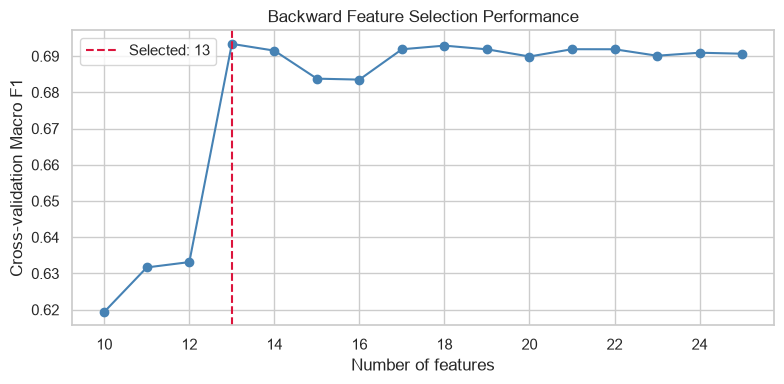

In [34]:
plot_selection = selection_results.sort_values("number_of_features")
plt.figure(figsize=(8, 4))
plt.plot(plot_selection.number_of_features, plot_selection.cv_f1_macro,
         marker="o", color="steelblue")
plt.axvline(best_k, color="crimson", linestyle="--", label=f"Selected: {best_k}")
plt.xlabel("Number of features")
plt.ylabel("Cross-validation Macro F1")
plt.title("Backward Feature Selection Performance")
plt.legend()
plt.tight_layout()
plt.savefig(RESULTS_DIR / "backward_feature_selection.png", dpi=150)
plt.show()

Save the selected features and build the final matrices.

In [35]:
full_removal_history_df = pd.DataFrame(removal_history)
selected_features_df = pd.DataFrame({
    "selection_order": range(1, len(selected_features) + 1),
    "feature": selected_features
})

selected_features_df.to_csv(RESULTS_DIR / "selected_features.csv", index=False)
full_removal_history_df.to_csv(RESULTS_DIR / "backward_removal_history.csv", index=False)

X_train_selected = X_train_processed[selected_features]
X_test_selected = X_test_processed[selected_features]

print("Final selected feature count:", X_train_selected.shape[1])
display(selected_features_df)

Final selected feature count: 13


,selection_order,feature
0,1,f4
1,2,f5
2,3,f25
3,4,duration_minutes
4,5,start_month
5,6,text_length
6,7,word_count
7,8,has_accident
8,9,has_crash
9,10,has_blocked


# 8. Model training and tuning

Tune each course-approved classifier with a compact, reproducible cross-validation search on the training data.

In [36]:
def choose_parameter(model_builder, parameter_values):
    rows = []
    for value in parameter_values:
        model = model_builder(value)
        score = cross_val_score(model, X_train_selected, y_train, cv=cv,
                                scoring="f1_macro", n_jobs=-1).mean()
        rows.append({"parameter": value, "cv_f1_macro": score})
    table = pd.DataFrame(rows)
    best_value = table.loc[table.cv_f1_macro.idxmax(), "parameter"]
    display(table)
    return best_value

def metric_row(name, truth, prediction):
    return {
        "Model": name,
        "Accuracy": accuracy_score(truth, prediction),
        "Precision macro": precision_score(truth, prediction, average="macro", zero_division=0),
        "Recall macro": recall_score(truth, prediction, average="macro", zero_division=0),
        "F1 macro": f1_score(truth, prediction, average="macro", zero_division=0),
        "Precision weighted": precision_score(truth, prediction, average="weighted", zero_division=0),
        "Recall weighted": recall_score(truth, prediction, average="weighted", zero_division=0),
        "F1 weighted": f1_score(truth, prediction, average="weighted", zero_division=0)
    }

results = []
predictions = {}
models = {}

## Model 1: Logistic Regression

Tune `C`.

In [37]:
best_C = float(choose_parameter(
    lambda value: LogisticRegression(C=float(value), max_iter=1000, random_state=RANDOM_STATE),
    [0.1, 1.0, 10.0]
))
logistic_model = LogisticRegression(C=best_C, max_iter=1000, random_state=RANDOM_STATE)
logistic_model.fit(X_train_selected, y_train)
models["Logistic Regression"] = logistic_model
print("Chosen C:", best_C)

,parameter,cv_f1_macro
0,0.1,0.551463
1,1.0,0.554642
2,10.0,0.554639


Chosen C: 1.0


Predict on the test set.

In [38]:
logistic_prediction = logistic_model.predict(X_test_selected)
predictions["Logistic Regression"] = logistic_prediction

Calculate the final metrics.

In [39]:
logistic_metrics = metric_row("Logistic Regression", y_test, logistic_prediction)
results.append(logistic_metrics)
display(pd.DataFrame([logistic_metrics]).set_index("Model"))

,Accuracy,Precision macro,Recall macro,F1 macro,Precision weighted,Recall weighted,F1 weighted
Model,,,,,,,
Logistic Regression,0.844427,0.645417,0.512642,0.548165,0.836796,0.844427,0.838574


## Model 2: Decision Tree

Tune the maximum depth.

In [40]:
best_depth = int(choose_parameter(
    lambda value: DecisionTreeClassifier(max_depth=int(value), random_state=RANDOM_STATE),
    [5, 8, 12]
))
tree_model = DecisionTreeClassifier(max_depth=best_depth, random_state=RANDOM_STATE)
tree_model.fit(X_train_selected, y_train)
models["Decision Tree"] = tree_model
print("Chosen max_depth:", best_depth)

,parameter,cv_f1_macro
0,5,0.551750
1,8,0.693382
2,12,0.702151


Chosen max_depth: 12


Predict on the test set.

In [41]:
tree_prediction = tree_model.predict(X_test_selected)
predictions["Decision Tree"] = tree_prediction

Calculate the final metrics.

In [42]:
tree_metrics = metric_row("Decision Tree", y_test, tree_prediction)
results.append(tree_metrics)
display(pd.DataFrame([tree_metrics]).set_index("Model"))

,Accuracy,Precision macro,Recall macro,F1 macro,Precision weighted,Recall weighted,F1 weighted
Model,,,,,,,
Decision Tree,0.86978,0.773671,0.662443,0.709035,0.865405,0.86978,0.866429


## Model 3: Gaussian Naive Bayes

Tune variance smoothing.

In [43]:
best_smoothing = float(choose_parameter(
    lambda value: GaussianNB(var_smoothing=float(value)),
    [1e-9, 1e-7, 1e-5]
))
nb_model = GaussianNB(var_smoothing=best_smoothing)
nb_model.fit(X_train_selected, y_train)
models["Gaussian Naive Bayes"] = nb_model
print("Chosen var_smoothing:", best_smoothing)

,parameter,cv_f1_macro
0,1.000000e-09,0.393110
1,1.000000e-07,0.393147
2,1.000000e-05,0.394030


Chosen var_smoothing: 1e-05


Predict on the test set.

In [44]:
nb_prediction = nb_model.predict(X_test_selected)
predictions["Gaussian Naive Bayes"] = nb_prediction

Calculate the final metrics.

In [45]:
nb_metrics = metric_row("Gaussian Naive Bayes", y_test, nb_prediction)
results.append(nb_metrics)
display(pd.DataFrame([nb_metrics]).set_index("Model"))

,Accuracy,Precision macro,Recall macro,F1 macro,Precision weighted,Recall weighted,F1 weighted
Model,,,,,,,
Gaussian Naive Bayes,0.487473,0.415657,0.72677,0.400321,0.822966,0.487473,0.535998


## Model 4: k-Nearest Neighbors (k-NN)

Choose `k` on a reproducible training subset, then fit the final model on all training data.

In [46]:
X_knn_tune, _, y_knn_tune, _ = train_test_split(
    X_train_selected,
    y_train,
    train_size=min(20000, len(X_train_selected)),
    random_state=RANDOM_STATE,
    stratify=y_train
)

knn_rows = []
for k in [3, 5, 7]:
    knn_candidate = KNeighborsClassifier(n_neighbors=k)
    score = cross_val_score(
        knn_candidate, X_knn_tune, y_knn_tune,
        cv=cv, scoring="f1_macro", n_jobs=-1
    ).mean()
    knn_rows.append({"n_neighbors": k, "cv_f1_macro": score})

knn_tuning = pd.DataFrame(knn_rows)
display(knn_tuning)
best_k_neighbors = int(knn_tuning.loc[knn_tuning.cv_f1_macro.idxmax(), "n_neighbors"])

knn_model = KNeighborsClassifier(n_neighbors=best_k_neighbors, n_jobs=-1)
knn_model.fit(X_train_selected, y_train)
models["K-Nearest Neighbors"] = knn_model
print("Chosen n_neighbors:", best_k_neighbors)

,n_neighbors,cv_f1_macro
0,3,0.653166
1,5,0.674083
2,7,0.667965


Chosen n_neighbors: 5


Predict on the test set.

In [47]:
knn_prediction = knn_model.predict(X_test_selected)
predictions["K-Nearest Neighbors"] = knn_prediction

Calculate the final metrics.

In [48]:
knn_metrics = metric_row("K-Nearest Neighbors", y_test, knn_prediction)
results.append(knn_metrics)
display(pd.DataFrame([knn_metrics]).set_index("Model"))

,Accuracy,Precision macro,Recall macro,F1 macro,Precision weighted,Recall weighted,F1 weighted
Model,,,,,,,
K-Nearest Neighbors,0.855778,0.765425,0.657077,0.703033,0.851086,0.855778,0.852545


## Model 5: Linear SVM

Tune `C` for a scalable linear SVM.

In [49]:
best_svm_C = float(choose_parameter(
    lambda value: LinearSVC(C=float(value), max_iter=5000, random_state=RANDOM_STATE),
    [0.01, 0.1, 1.0]
))
svm_model = LinearSVC(C=best_svm_C, max_iter=5000, random_state=RANDOM_STATE)
svm_model.fit(X_train_selected, y_train)
models["Linear SVM"] = svm_model
print("Chosen C:", best_svm_C)

,parameter,cv_f1_macro
0,0.01,0.534818
1,0.10,0.535103
2,1.00,0.535103


Chosen C: 0.1


Predict on the test set.

In [50]:
svm_prediction = svm_model.predict(X_test_selected)
predictions["Linear SVM"] = svm_prediction

Calculate the final metrics.

In [51]:
svm_metrics = metric_row("Linear SVM", y_test, svm_prediction)
results.append(svm_metrics)
display(pd.DataFrame([svm_metrics]).set_index("Model"))

,Accuracy,Precision macro,Recall macro,F1 macro,Precision weighted,Recall weighted,F1 weighted
Model,,,,,,,
Linear SVM,0.844027,0.591079,0.507105,0.538915,0.833936,0.844027,0.8376


# 9. Model evaluation

Compare held-out performance using macro precision, recall, F1, and accuracy. Macro F1 remains the primary decision criterion.

In [52]:
comparison_df = pd.DataFrame(results).sort_values(["F1 macro", "Accuracy"], ascending=False).reset_index(drop=True)
comparison_df.to_csv(RESULTS_DIR / "model_comparison.csv", index=False)
display(comparison_df.round(4))

,Model,Accuracy,Precision macro,Recall macro,F1 macro,Precision weighted,Recall weighted,F1 weighted
0,Decision Tree,0.8698,0.7737,0.6624,0.7090,0.8654,0.8698,0.8664
1,K-Nearest Neighbors,0.8558,0.7654,0.6571,0.7030,0.8511,0.8558,0.8525
2,Logistic Regression,0.8444,0.6454,0.5126,0.5482,0.8368,0.8444,0.8386
3,Linear SVM,0.8440,0.5911,0.5071,0.5389,0.8339,0.8440,0.8376
4,Gaussian Naive Bayes,0.4875,0.4157,0.7268,0.4003,0.8230,0.4875,0.5360


### Overall comparison

Compare macro precision, recall, F1, and accuracy across models.

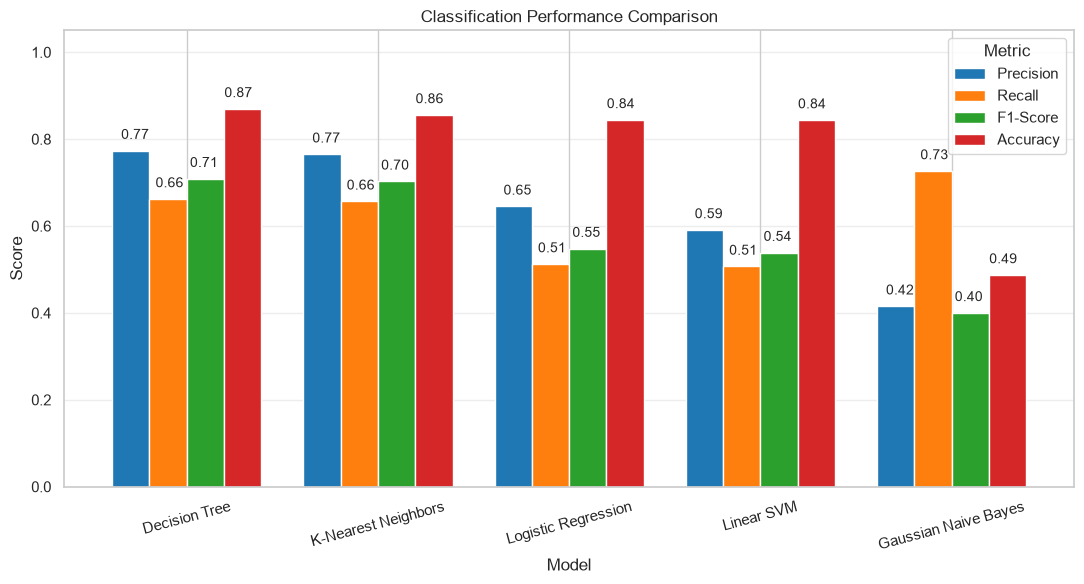

In [53]:
comparison_plot = comparison_df.set_index("Model")[[
    "Precision macro", "Recall macro", "F1 macro", "Accuracy"
]].rename(columns={
    "Precision macro": "Precision",
    "Recall macro": "Recall",
    "F1 macro": "F1-Score"
})

ax = comparison_plot.plot(
    kind="bar",
    figsize=(11, 6),
    width=0.78,
    color=["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"]
)
ax.set_ylim(0, 1.05)
ax.set_xlabel("Model")
ax.set_ylabel("Score")
ax.set_title("Classification Performance Comparison")
ax.tick_params(axis="x", rotation=15)
ax.legend(title="Metric", loc="upper right")
ax.grid(axis="y", alpha=0.35)

for c_idx, col in enumerate(comparison_plot.columns):
    for idx, v in enumerate(comparison_plot[col]):
        ax.text(
            idx + (c_idx - 1.5)*0.18,  # slight offset per bar; width/num_bars ~ 0.78/4 ≈ 0.18
            v + 0.02,
            f"{v:.2f}",
            ha='center',
            va='bottom',
            fontsize=10
        )

plt.tight_layout()
plt.savefig(RESULTS_DIR / "model_metrics_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

Rank models by macro F1.

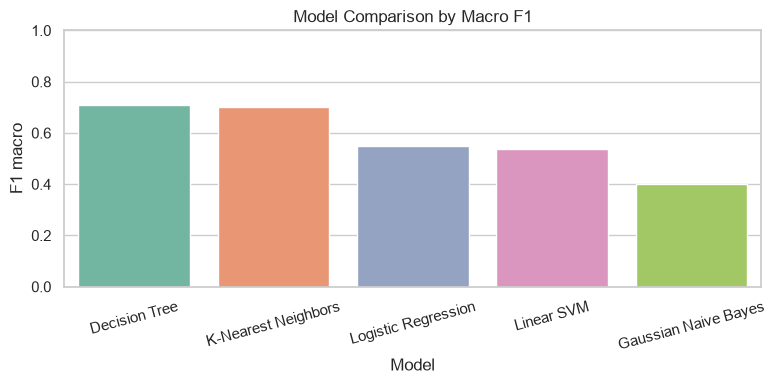

In [54]:
plt.figure(figsize=(8, 4))
sns.barplot(data=comparison_df, x="Model", y="F1 macro", hue="Model", palette="Set2", legend=False)
plt.ylim(0, 1); plt.title("Model Comparison by Macro F1"); plt.xticks(rotation=15)
plt.tight_layout(); plt.show()

Compare accuracy with class imbalance in mind.

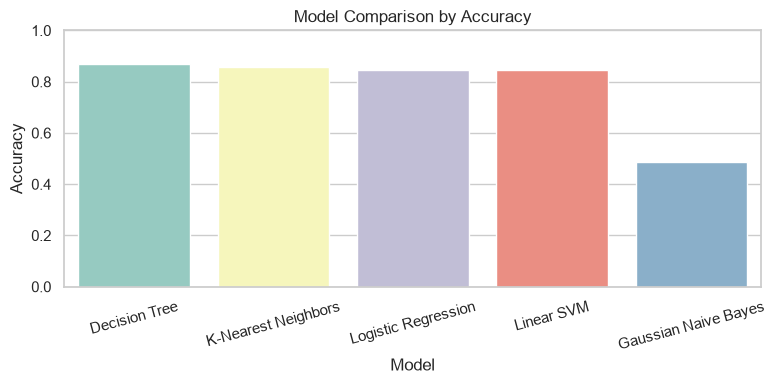

In [55]:
plt.figure(figsize=(8, 4))
sns.barplot(data=comparison_df, x="Model", y="Accuracy", hue="Model", palette="Set3", legend=False)
plt.ylim(0, 1); plt.title("Model Comparison by Accuracy"); plt.xticks(rotation=15)
plt.tight_layout(); plt.show()

# 10. Final model

Select the model with the highest held-out macro F1; accuracy is used only to break a tie.

In [56]:
final_model_name = comparison_df.iloc[0]["Model"]
final_model = models[final_model_name]
final_prediction = predictions[final_model_name]
final_metrics = comparison_df.iloc[0]
final_cm = confusion_matrix(y_test, final_prediction, labels=sorted(y.unique()))

print("Final model:", final_model_name)
print("Selected features:", selected_features)
print("Number of selected features:", len(selected_features))
for metric in ["Accuracy", "Precision macro", "Recall macro", "F1 macro"]:
    print(f"{metric}: {final_metrics[metric]:.4f}")

Final model: Decision Tree
Selected features: ['f4', 'f5', 'f25', 'duration_minutes', 'start_month', 'text_length', 'word_count', 'has_accident', 'has_crash', 'has_blocked', 'has_closed', 'f1_Source1', 'f10_Other']
Number of selected features: 13
Accuracy: 0.8698
Precision macro: 0.7737
Recall macro: 0.6624
F1 macro: 0.7090


Show and save the confusion matrix.

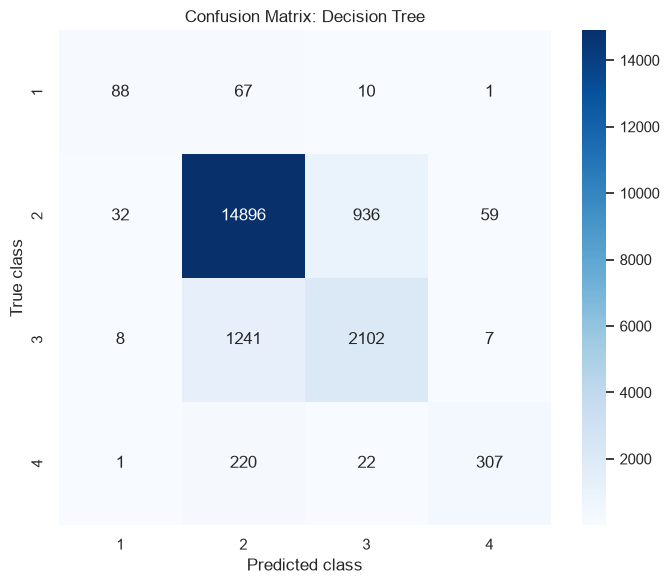

In [57]:
class_labels = sorted(y.unique())
plt.figure(figsize=(7, 6))
sns.heatmap(final_cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel("Predicted class"); plt.ylabel("True class")
plt.title(f"Confusion Matrix: {final_model_name}")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "confusion_matrix.png", dpi=150)
plt.show()

Show the class-level report.

In [58]:
report_dict = classification_report(y_test, final_prediction, output_dict=True, zero_division=0)
report_df = pd.DataFrame(report_dict).T
display(report_df)

,precision,recall,f1-score,support
1,0.682171,0.530120,0.596610,166.00000
2,0.906965,0.935502,0.921013,15923.00000
3,0.684691,0.625968,0.654014,3358.00000
4,0.820856,0.558182,0.664502,550.00000
accuracy,0.869780,0.869780,0.869780,0.86978
macro avg,0.773671,0.662443,0.709035,19997.00000
weighted avg,0.865405,0.869780,0.866429,19997.00000


The final choice balances class performance, accuracy, simplicity, and interpretability.

# 11. Save outputs

Save the final metrics, class-level report, selected features, and confusion matrix for reproducible reporting.

In [59]:
report_df.to_csv(RESULTS_DIR / "final_classification_report.csv")
final_metrics_df = pd.DataFrame([final_metrics]).reset_index(drop=True)
final_metrics_df.insert(1, "number_of_selected_features", len(selected_features))
final_metrics_df.to_csv(RESULTS_DIR / "final_model_metrics.csv", index=False)

# Final summary

A concise, automatically generated summary of the model comparison and the selected final model.

In [60]:
summary = f''' 
**Compared models:** Logistic Regression, Decision Tree, Gaussian Naive Bayes, k-Nearest Neighbors, and Linear SVM.  
**Final model:** {final_model_name}.
**Final test metrics:** accuracy {final_metrics['Accuracy']:.4f}, macro precision {final_metrics['Precision macro']:.4f}, macro recall {final_metrics['Recall macro']:.4f}, and macro F1 {final_metrics['F1 macro']:.4f}.  
'''
display(Markdown(summary))

 
**Compared models:** Logistic Regression, Decision Tree, Gaussian Naive Bayes, k-Nearest Neighbors, and Linear SVM.  
**Final model:** Decision Tree.
**Final test metrics:** accuracy 0.8698, macro precision 0.7737, macro recall 0.6624, and macro F1 0.7090.  


# 12. Evaluation on the additional test set

Apply the complete fitted pipeline to `../data/test.csv` and report its performance without refitting any preprocessing or model component.

In [ ]:
test_data = pd.read_csv(DATA_DIR / "test.csv")
y_new = test_data[target_column]
X_new, _ = create_features(test_data.drop(columns=target_column))

X_num = X_new[train_numeric].astype(float).fillna(numeric_medians)
X_num = pd.DataFrame(scaler.transform(X_num), columns=train_numeric, index=X_new.index)
X_cat = X_new[train_categorical].copy()
for col in train_categorical:
    X_cat[col] = X_cat[col].fillna(category_fill_values[col]).astype(str).str.strip()
    X_cat[col] = X_cat[col].where(X_cat[col].isin(kept_categories[col]), "Other")

X_new = pd.concat([X_num, pd.get_dummies(X_cat, prefix=train_categorical, dtype=float)], axis=1)
X_new = X_new.reindex(columns=X_train_processed.columns, fill_value=0)[selected_features]
y_pred = final_model.predict(X_new)

metrics = metric_row(final_model_name, y_new, y_pred)
display(pd.DataFrame([metrics]).set_index("Model").round(4))

shown_rows = test_data.head(10).copy()
shown_rows["predicted_label"] = y_pred[:10]
display(shown_rows)

,Accuracy,Precision macro,Recall macro,F1 macro,Precision weighted,Recall weighted,F1 weighted
Model,,,,,,,
Decision Tree,0.87,0.7643,0.6682,0.7084,0.8662,0.87,0.867


,f1,f2,f3,f4,f5,f6,f7,f8,f9,f10,...,f27,f28,f29,f30,f31,f32,f33,f34,y,predicted_label
0,Source1,2022-06-11 09:10:48,2022-06-11 15:15:00,30.652083,-87.775320,30.653927,-87.791511,0.971,Incident on I-10 WB near MM 44 Drive with caut...,I-10 W,...,False,False,False,False,False,False,False,Day,2,2
1,Source1,2020-11-29 14:36:10,2020-11-29 16:44:07,38.880904,-77.221988,38.873564,-77.220408,0.514,Incident on I-495 SB near MM 49 Expect delays.,Capital Beltway S,...,True,False,False,False,False,False,False,Day,2,2
2,Source2,2017-06-19 09:56:49,2017-06-19 10:26:16,34.007256,-117.965225,NaN,NaN,0.000,#1 lane blocked due to accident on CA-60 Westb...,Pomona Fwy W,...,False,False,False,False,False,False,False,Day,2,2
3,Source2,2018-02-09 07:57:58,2018-02-09 08:27:37,43.002140,-83.749329,NaN,NaN,0.000,Accident on I-75 Northbound at M-21 Corunna Rd.,I-75 N,...,False,False,False,False,False,False,False,Day,3,2
4,Source2,2020-11-23 08:18:54,2020-11-23 09:06:12,33.874981,-118.215683,NaN,NaN,0.390,Accident on exit ramp from CA-91 Westbound to ...,E Artesia Blvd,...,False,False,False,False,False,False,False,Day,2,2
5,Source2,2018-03-21 08:21:45,2018-03-21 08:51:17,31.294901,-94.627304,NaN,NaN,0.000,Accident on FM-326 near Yellowood Rd.,Yellowood Rd,...,False,False,False,False,False,False,False,Day,2,2
6,Source1,2020-09-28 19:50:00,2020-09-28 21:52:46,40.010629,-75.207692,40.012529,-75.210812,0.211,Incident on I-76 WB near US-1 Road closed. Tak...,I-76 W,...,True,False,False,False,False,False,False,Night,4,2
7,Source1,2022-01-04 17:48:00.000000000,2022-01-04 19:52:00.000000000,37.617284,-122.154526,37.564964,-122.272026,7.379,Stationary traffic on J Arthur Younger Fwy W -...,CA-92,...,False,False,False,False,False,False,False,Night,2,2
8,Source1,2022-08-09 11:40:14,2022-08-09 12:15:29,40.654631,-73.860763,40.603872,-73.899432,4.051,Stationary traffic on Belt Pkwy W from Crossba...,Belt Pkwy W,...,False,False,False,False,False,False,False,Day,2,2
9,Source2,2019-08-08 08:51:32,2019-08-08 09:54:58,35.468861,-97.519211,NaN,NaN,0.000,Accident on Park Ave in Business District.,Park Ave,...,False,False,True,False,True,False,False,Day,2,2
